In [1]:
import os
from phonopy import Phonopy
from phonopy.interface.vasp import read_vasp ,write_vasp

os.system('phonopy -d --dim=" 6 6 1" --tolerance=1e-6')

0

In [1]:
import os 
from phonopy import Phonopy

os.system('phonopy -f {001..4}-vasprun.xml')

1

In [2]:
import os 
from phonopy import Phonopy

os.system('phonopy -p -s band.conf')

0

Loaded 204 q-points, 6 bands
Distance range: 0.0000 → 0.4803
Segment boundaries at: [np.float64(0.0), np.float64(0.1427023), np.float64(0.2662861), np.float64(0.3376372), np.float64(0.4803395)]
Frequency range: -0.9326 → 139.6059 THz

distances.shape  = (204,)
frequencies.shape = (204, 6)


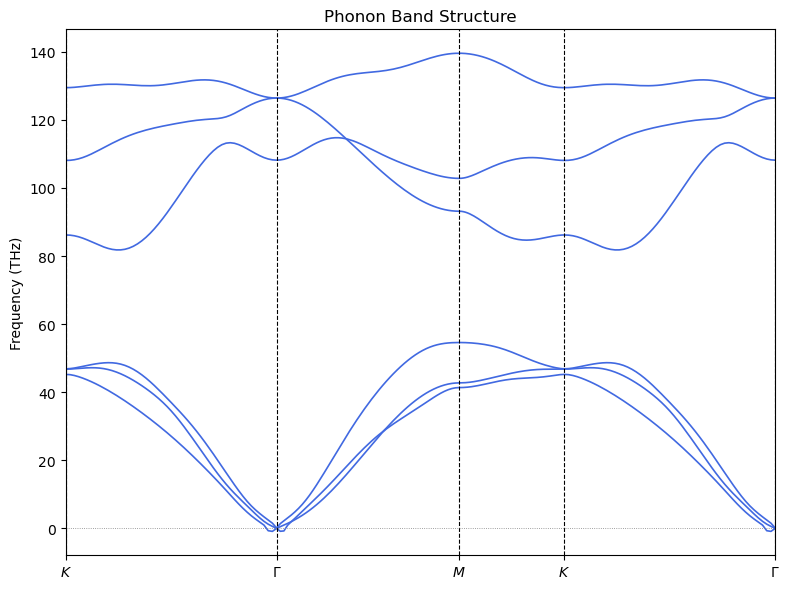

In [3]:
import yaml
import numpy as np
import matplotlib.pyplot as plt

def parse_band_yaml(filepath):
    """Parse phonopy band.yaml and return kpoints distances and frequencies."""
    with open(filepath, 'r') as f:
        data = yaml.safe_load(f)

    nqpoint = data['nqpoint']
    segment_nqpoint = data['segment_nqpoint']

    # Extract distances along the path and frequencies
    distances = []
    frequencies = []

    for phonon in data['phonon']:
        distances.append(phonon['distance'])
        freqs = [band['frequency'] for band in phonon['band']]
        frequencies.append(freqs)

    distances = np.array(distances)        # shape: (nqpoint,)
    frequencies = np.array(frequencies)   # shape: (nqpoint, nbands)

    # Find segment boundary x-positions (for high-symmetry point markers)
    segment_boundaries = []
    idx = 0
    for seg_nq in segment_nqpoint:
        segment_boundaries.append(distances[idx])
        idx += seg_nq
    segment_boundaries.append(distances[-1])  # add final point

    return distances, frequencies, segment_boundaries


labels = [r'$K$',r'$\Gamma$', r'$M$', r'$K$', r'$\Gamma$']

def plot_bands(distances, frequencies, segment_boundaries,
               ylabel="Frequency (THz)", title="Phonon Band Structure"):
    """Plot phonon band structure."""
    fig, ax = plt.subplots(figsize=(8, 6))

    nbands = frequencies.shape[1]
    for i in range(nbands):
        ax.plot(distances, frequencies[:, i], color='royalblue', linewidth=1.2)

    # Draw vertical lines at segment boundaries
    for xb in segment_boundaries:
        ax.axvline(x=xb, color='black', linewidth=0.8, linestyle='--')

    # Draw horizontal line at zero frequency
    ax.axhline(y=0, color='gray', linewidth=0.6, linestyle=':')

    ax.set_xlim(distances[0], distances[-1])
    ax.set_xticks(segment_boundaries)
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.tight_layout()
    #plt.savefig("phonon_bands.png", dpi=150)
    plt.show()
    #print("Saved to phonon_bands.png")


if __name__ == "__main__":
    filepath = "band.yaml"

    distances, frequencies, segment_boundaries = parse_band_yaml(filepath)

    print(f"Loaded {len(distances)} q-points, {frequencies.shape[1]} bands")
    print(f"Distance range: {distances[0]:.4f} → {distances[-1]:.4f}")
    print(f"Segment boundaries at: {segment_boundaries}")
    print(f"Frequency range: {frequencies.min():.4f} → {frequencies.max():.4f} THz")
    print(f"\ndistances.shape  = {distances.shape}")
    print(f"frequencies.shape = {frequencies.shape}")

    plot_bands(distances, frequencies, segment_boundaries)
